# Model Comparison: Random Forest vs LightGBM vs XGBoost

## Recruit Restaurant Visitor Forecasting

This notebook compares three popular tree-based models for the visitor forecasting task.

### References
- [8th Place Solution (LightGBM)](https://github.com/MaxHalford/kaggle-recruit-restaurant)
- [Kaggle Days Solution](https://github.com/dkivaranovic/kaggledays-recruit)
- [Competition Page](https://www.kaggle.com/c/recruit-restaurant-visitor-forecasting)

## 1. Setup and Imports

In [1]:
import sys
sys.path.append('../../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Models
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb
import xgboost as xgb

# Metrics
from sklearn.metrics import mean_squared_error

# Utilities
from src.utils import seed_everything, reduce_mem_usage

seed_everything(42)

%matplotlib inline
plt.rcParams['font.family'] = 'MS Gothic'
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 100)

INPUT_DIR = Path('../input')
OUTPUT_DIR = Path('../output')

## 2. RMSLE Metric

The competition uses **Root Mean Squared Logarithmic Error (RMSLE)**:

$$RMSLE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(\log(\hat{y_i}+1)-\log(y_i+1))^2}$$

### Why RMSLE?
- Penalizes **underprediction** more than overprediction
- Better for restaurants: running out of food is worse than having extra
- Handles large value discrepancies proportionally

In [2]:
def rmsle(y_true, y_pred):
    """Root Mean Squared Logarithmic Error"""
    y_pred = np.clip(y_pred, 0, None)  # Ensure non-negative predictions
    return np.sqrt(mean_squared_error(
        np.log1p(y_true), 
        np.log1p(y_pred)
    ))

# For LightGBM custom metric
def lgb_rmsle(y_pred, data):
    y_true = data.get_label()
    score = rmsle(y_true, y_pred)
    return 'rmsle', score, False

# For XGBoost custom metric
def xgb_rmsle(y_pred, dtrain):
    y_true = dtrain.get_label()
    score = rmsle(y_true, y_pred)
    return 'rmsle', score

## 3. Load and Prepare Data

In [3]:
# Load data
air_visit = pd.read_csv(INPUT_DIR / 'air_visit_data.csv', parse_dates=['visit_date'])
air_store = pd.read_csv(INPUT_DIR / 'air_store_info.csv')
date_info = pd.read_csv(INPUT_DIR / 'date_info.csv', parse_dates=['calendar_date'])

print(f'Visits: {air_visit.shape}')
print(f'Stores: {air_store.shape}')
print(f'Dates: {date_info.shape}')

Visits: (252108, 3)
Stores: (829, 5)
Dates: (517, 3)


In [4]:
# Merge store info
df = air_visit.merge(air_store, on='air_store_id', how='left')

# Merge date info
df = df.merge(
    date_info.rename(columns={'calendar_date': 'visit_date'}),
    on='visit_date',
    how='left'
)

print(f'Merged data: {df.shape}')
df.head()

Merged data: (252108, 9)


,air_store_id,visit_date,visitors,air_genre_name,air_area_name,latitude,longitude,day_of_week,holiday_flg
0,air_ba937bf13d40fb24,2016-01-13,25,Dining bar,Tōkyō-to Minato-ku Shibakōen,35.658068,139.751599,Wednesday,0
1,air_ba937bf13d40fb24,2016-01-14,32,Dining bar,Tōkyō-to Minato-ku Shibakōen,35.658068,139.751599,Thursday,0
2,air_ba937bf13d40fb24,2016-01-15,29,Dining bar,Tōkyō-to Minato-ku Shibakōen,35.658068,139.751599,Friday,0
3,air_ba937bf13d40fb24,2016-01-16,22,Dining bar,Tōkyō-to Minato-ku Shibakōen,35.658068,139.751599,Saturday,0
4,air_ba937bf13d40fb24,2016-01-18,6,Dining bar,Tōkyō-to Minato-ku Shibakōen,35.658068,139.751599,Monday,0


## 4. Feature Engineering

### Key techniques from top solutions:
1. **Rolling statistics** (mean, std, min, max)
2. **Lag features** (same weekday previous weeks)
3. **Time features** (day of week, month, etc.)
4. **Holiday features**

In [5]:
def create_features(df):
    """Create features based on top solutions."""
    df = df.copy()
    
    # Time features
    df['year'] = df['visit_date'].dt.year
    df['month'] = df['visit_date'].dt.month
    df['day'] = df['visit_date'].dt.day
    df['dow'] = df['visit_date'].dt.dayofweek  # 0=Monday
    df['week'] = df['visit_date'].dt.isocalendar().week.astype(int)
    df['is_weekend'] = (df['dow'] >= 5).astype(int)
    
    # Holiday features (from date_info)
    df['is_holiday'] = df['holiday_flg'].fillna(0).astype(int)
    
    # Encode categorical features
    df['genre_encoded'] = df['air_genre_name'].factorize()[0]
    df['area_encoded'] = df['air_area_name'].factorize()[0]
    
    return df

df = create_features(df)
df.head()

,air_store_id,visit_date,visitors,air_genre_name,air_area_name,latitude,longitude,day_of_week,holiday_flg,year,month,day,dow,week,is_weekend,is_holiday,genre_encoded,area_encoded
0,air_ba937bf13d40fb24,2016-01-13,25,Dining bar,Tōkyō-to Minato-ku Shibakōen,35.658068,139.751599,Wednesday,0,2016,1,13,2,2,0,0,0,0
1,air_ba937bf13d40fb24,2016-01-14,32,Dining bar,Tōkyō-to Minato-ku Shibakōen,35.658068,139.751599,Thursday,0,2016,1,14,3,2,0,0,0,0
2,air_ba937bf13d40fb24,2016-01-15,29,Dining bar,Tōkyō-to Minato-ku Shibakōen,35.658068,139.751599,Friday,0,2016,1,15,4,2,0,0,0,0
3,air_ba937bf13d40fb24,2016-01-16,22,Dining bar,Tōkyō-to Minato-ku Shibakōen,35.658068,139.751599,Saturday,0,2016,1,16,5,2,1,0,0,0
4,air_ba937bf13d40fb24,2016-01-18,6,Dining bar,Tōkyō-to Minato-ku Shibakōen,35.658068,139.751599,Monday,0,2016,1,18,0,3,0,0,0,0


In [6]:
def create_rolling_features(df, windows=[7, 14, 21, 35]):
    """Create rolling statistics per store.
    
    Based on top solutions:
    - 8th place: focused on rolling statistics
    - 11th place: rolling weighted mean
    """
    df = df.sort_values(['air_store_id', 'visit_date']).reset_index(drop=True)
    
    for window in windows:
        # Group by store and calculate rolling stats
        grouped = df.groupby('air_store_id')['visitors']
        
        df[f'rolling_mean_{window}'] = grouped.transform(
            lambda x: x.shift(1).rolling(window, min_periods=1).mean()
        )
        df[f'rolling_std_{window}'] = grouped.transform(
            lambda x: x.shift(1).rolling(window, min_periods=1).std()
        )
        df[f'rolling_min_{window}'] = grouped.transform(
            lambda x: x.shift(1).rolling(window, min_periods=1).min()
        )
        df[f'rolling_max_{window}'] = grouped.transform(
            lambda x: x.shift(1).rolling(window, min_periods=1).max()
        )
    
    # Exponentially weighted mean (from 11th place solution)
    df['ewm_mean'] = df.groupby('air_store_id')['visitors'].transform(
        lambda x: x.shift(1).ewm(span=7).mean()
    )
    
    return df

df = create_rolling_features(df)
print(f'Features created: {df.shape[1]} columns')

Features created: 35 columns


In [7]:
def create_lag_features(df, lags=[7, 14, 21, 28]):
    """Create lag features (same day previous weeks)."""
    df = df.sort_values(['air_store_id', 'visit_date']).reset_index(drop=True)
    
    for lag in lags:
        df[f'lag_{lag}'] = df.groupby('air_store_id')['visitors'].shift(lag)
    
    return df

df = create_lag_features(df)
print(f'Total features: {df.shape[1]} columns')

Total features: 39 columns


## 5. Prepare Train/Validation Split

### Important: Time Series Validation

**DO NOT use random split** for time series data!

From top solutions:
- Use rolling/expanding window validation
- Train on past, validate on future

In [8]:
# Define feature columns
FEATURE_COLS = [
    'year', 'month', 'day', 'dow', 'week', 'is_weekend', 'is_holiday',
    'genre_encoded', 'area_encoded',
    'rolling_mean_7', 'rolling_std_7', 'rolling_min_7', 'rolling_max_7',
    'rolling_mean_14', 'rolling_std_14', 'rolling_min_14', 'rolling_max_14',
    'rolling_mean_21', 'rolling_std_21', 'rolling_min_21', 'rolling_max_21',
    'rolling_mean_35', 'rolling_std_35', 'rolling_min_35', 'rolling_max_35',
    'ewm_mean',
    'lag_7', 'lag_14', 'lag_21', 'lag_28'
]

TARGET_COL = 'visitors'

# Remove rows with NaN (due to rolling/lag features)
df_clean = df.dropna(subset=FEATURE_COLS + [TARGET_COL]).copy()
print(f'Clean data: {df_clean.shape}')

Clean data: (228904, 39)


In [9]:
# Time-based split
# Train: before 2017-03-01
# Validation: 2017-03-01 onwards

SPLIT_DATE = '2017-03-01'

train_mask = df_clean['visit_date'] < SPLIT_DATE
valid_mask = df_clean['visit_date'] >= SPLIT_DATE

X_train = df_clean.loc[train_mask, FEATURE_COLS]
y_train = df_clean.loc[train_mask, TARGET_COL]
X_valid = df_clean.loc[valid_mask, FEATURE_COLS]
y_valid = df_clean.loc[valid_mask, TARGET_COL]

print(f'Train: {X_train.shape}')
print(f'Valid: {X_valid.shape}')

Train: (191000, 30)
Valid: (37904, 30)


## 6. Model Training and Comparison

### Models to compare:
1. **Random Forest** - Baseline, robust to outliers
2. **LightGBM** - Fast, used by 8th place solution
3. **XGBoost** - Robust, good generalization

### 6.1 Random Forest

**Strengths:**
- Handles outliers well
- No need for feature scaling
- Good baseline model

**Weaknesses:**
- Slower than gradient boosting
- Memory intensive
- Less accurate than boosting for tabular data

In [10]:
%%time

rf_params = {
    'n_estimators': 100,
    'max_depth': 10,
    'min_samples_split': 10,
    'min_samples_leaf': 5,
    'n_jobs': -1,
    'random_state': 42
}

rf_model = RandomForestRegressor(**rf_params)
rf_model.fit(X_train, y_train)

rf_pred_train = rf_model.predict(X_train)
rf_pred_valid = rf_model.predict(X_valid)

rf_train_score = rmsle(y_train, rf_pred_train)
rf_valid_score = rmsle(y_valid, rf_pred_valid)

print(f'Random Forest - Train RMSLE: {rf_train_score:.5f}')
print(f'Random Forest - Valid RMSLE: {rf_valid_score:.5f}')

Random Forest - Train RMSLE: 0.56463
Random Forest - Valid RMSLE: 0.57237
CPU times: total: 4min
Wall time: 42.7 s


### 6.2 LightGBM

**Most popular model in top solutions**

**Strengths:**
- Very fast training
- Handles categorical features natively
- Low memory usage
- Excellent accuracy

**8th Place Solution used:**
- LightGBM with cross-validation
- Focus on feature engineering

In [11]:
%%time

lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': -1,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

lgb_train = lgb.Dataset(X_train, label=np.log1p(y_train))  # Log transform target
lgb_valid = lgb.Dataset(X_valid, label=np.log1p(y_valid), reference=lgb_train)

lgb_model = lgb.train(
    lgb_params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_train, lgb_valid],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

# Predictions (inverse log transform)
lgb_pred_train = np.expm1(lgb_model.predict(X_train))
lgb_pred_valid = np.expm1(lgb_model.predict(X_valid))

lgb_train_score = rmsle(y_train, lgb_pred_train)
lgb_valid_score = rmsle(y_valid, lgb_pred_valid)

print(f'LightGBM - Train RMSLE: {lgb_train_score:.5f}')
print(f'LightGBM - Valid RMSLE: {lgb_valid_score:.5f}')

Training until validation scores don't improve for 50 rounds
[100]	training's rmse: 0.549752	valid_1's rmse: 0.54754
[200]	training's rmse: 0.539921	valid_1's rmse: 0.542047
[300]	training's rmse: 0.533337	valid_1's rmse: 0.539332
[400]	training's rmse: 0.527685	valid_1's rmse: 0.537586
[500]	training's rmse: 0.522474	valid_1's rmse: 0.536242
[600]	training's rmse: 0.518121	valid_1's rmse: 0.535406
[700]	training's rmse: 0.514148	valid_1's rmse: 0.534915
[800]	training's rmse: 0.510309	valid_1's rmse: 0.534396
[900]	training's rmse: 0.506754	valid_1's rmse: 0.533983
[1000]	training's rmse: 0.503325	valid_1's rmse: 0.533786
Did not meet early stopping. Best iteration is:
[988]	training's rmse: 0.50369	valid_1's rmse: 0.533755
LightGBM - Train RMSLE: 0.50369
LightGBM - Valid RMSLE: 0.53375
CPU times: total: 55.8 s
Wall time: 13.8 s


### 6.3 XGBoost

**Strengths:**
- Robust and well-tested
- Good generalization
- Built-in regularization

**Weaknesses:**
- Slower than LightGBM
- Higher memory usage

In [12]:
%%time

xgb_params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'learning_rate': 0.05,
    'max_depth': 6,
    'min_child_weight': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'random_state': 42,
    'n_jobs': -1
}

xgb_train = xgb.DMatrix(X_train, label=np.log1p(y_train))
xgb_valid = xgb.DMatrix(X_valid, label=np.log1p(y_valid))

xgb_model = xgb.train(
    xgb_params,
    xgb_train,
    num_boost_round=1000,
    evals=[(xgb_train, 'train'), (xgb_valid, 'valid')],
    early_stopping_rounds=50,
    verbose_eval=100
)

# Predictions
xgb_pred_train = np.expm1(xgb_model.predict(xgb_train))
xgb_pred_valid = np.expm1(xgb_model.predict(xgb_valid))

xgb_train_score = rmsle(y_train, xgb_pred_train)
xgb_valid_score = rmsle(y_valid, xgb_pred_valid)

print(f'XGBoost - Train RMSLE: {xgb_train_score:.5f}')
print(f'XGBoost - Valid RMSLE: {xgb_valid_score:.5f}')

[0]	train-rmse:0.78376	valid-rmse:0.80402
[100]	train-rmse:0.54542	valid-rmse:0.54676
[200]	train-rmse:0.53368	valid-rmse:0.54116
[300]	train-rmse:0.52652	valid-rmse:0.53953
[400]	train-rmse:0.52100	valid-rmse:0.53901
[500]	train-rmse:0.51510	valid-rmse:0.53778
[600]	train-rmse:0.50973	valid-rmse:0.53714
[660]	train-rmse:0.50688	valid-rmse:0.53722
XGBoost - Train RMSLE: 0.50688
XGBoost - Valid RMSLE: 0.53722
CPU times: total: 41.7 s
Wall time: 12.5 s


## 7. Results Comparison

In [13]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'LightGBM', 'XGBoost'],
    'Train RMSLE': [rf_train_score, lgb_train_score, xgb_train_score],
    'Valid RMSLE': [rf_valid_score, lgb_valid_score, xgb_valid_score]
})

results['Overfitting'] = results['Valid RMSLE'] - results['Train RMSLE']
results = results.sort_values('Valid RMSLE')

print('\n' + '='*60)
print('MODEL COMPARISON RESULTS')
print('='*60)
print(results.to_string(index=False))
print('='*60)


MODEL COMPARISON RESULTS
        Model  Train RMSLE  Valid RMSLE  Overfitting
     LightGBM     0.503690     0.533755     0.030064
      XGBoost     0.506879     0.537218     0.030339
Random Forest     0.564626     0.572365     0.007740


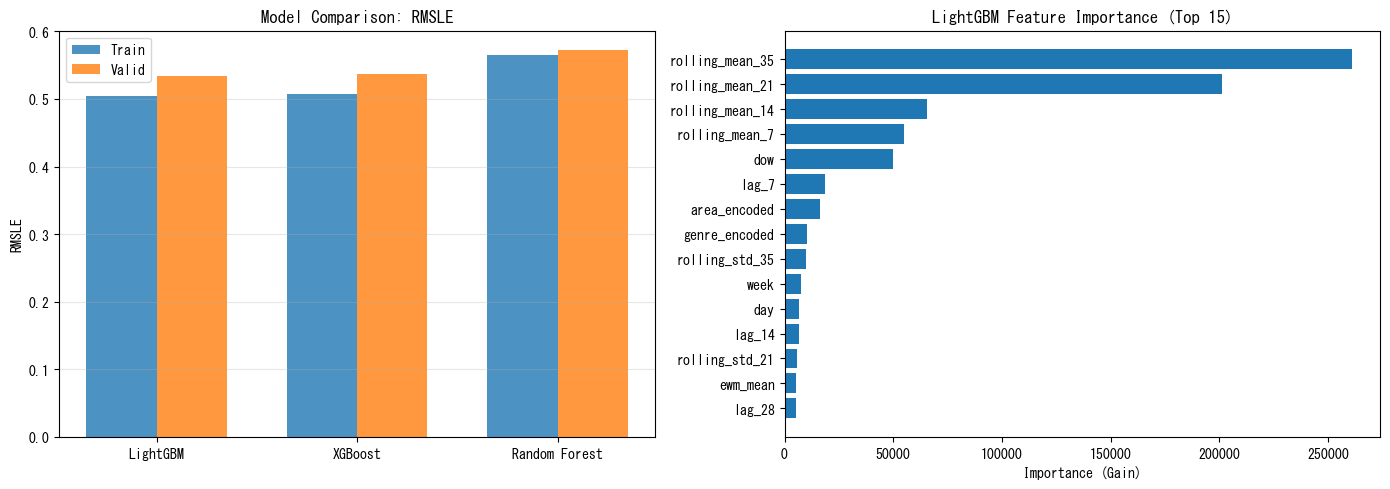

In [14]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSLE comparison
x = np.arange(len(results))
width = 0.35

axes[0].bar(x - width/2, results['Train RMSLE'], width, label='Train', alpha=0.8)
axes[0].bar(x + width/2, results['Valid RMSLE'], width, label='Valid', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(results['Model'])
axes[0].set_ylabel('RMSLE')
axes[0].set_title('Model Comparison: RMSLE')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Feature importance (LightGBM)
importance = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': lgb_model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=True).tail(15)

axes[1].barh(importance['feature'], importance['importance'])
axes[1].set_xlabel('Importance (Gain)')
axes[1].set_title('LightGBM Feature Importance (Top 15)')

plt.tight_layout()
plt.show()

## 8. Ensemble Method

From **3rd Place Kaggle Days Solution**:
- Weighted average of LightGBM and Keras improved score by ~0.004
- Simple averaging often works well

In [15]:
# Simple average ensemble
ensemble_pred = (lgb_pred_valid + xgb_pred_valid) / 2
ensemble_score = rmsle(y_valid, ensemble_pred)

print(f'Ensemble (LGB + XGB) - Valid RMSLE: {ensemble_score:.5f}')

# Weighted ensemble (more weight to better model)
weights = [0.6, 0.4]  # LGB, XGB
weighted_pred = weights[0] * lgb_pred_valid + weights[1] * xgb_pred_valid
weighted_score = rmsle(y_valid, weighted_pred)

print(f'Weighted Ensemble (0.6*LGB + 0.4*XGB) - Valid RMSLE: {weighted_score:.5f}')

Ensemble (LGB + XGB) - Valid RMSLE: 0.53466
Weighted Ensemble (0.6*LGB + 0.4*XGB) - Valid RMSLE: 0.53435


## 9. なぜLightGBMがランダムフォレストより優れるか

### バギング vs ブースティング

ランダムフォレストと勾配ブースティング（LightGBM/XGBoost）は、根本的に異なるアプローチをとる。

**ランダムフォレスト（バギング）:**
- 複数の決定木を**独立**に学習し、予測を**平均化**
- 各木はランダムなサブセットで学習 → 多様性を確保
- 利点: 過学習しにくい、外れ値に強い
- 欠点: 誤差を修正する仕組みがない

**LightGBM/XGBoost（ブースティング）:**
- 決定木を**逐次的**に追加し、前の木の**誤差を修正**
- 各木が「前のモデルが間違えたサンプル」に集中して学習
- 利点: より細かいパターンを捉えられる、精度が高い
- 欠点: 過学習のリスクがやや高い（正則化で対処）

### LightGBMがXGBoostより速い理由

| 項目 | XGBoost | LightGBM |
|------|---------|----------|
| 木の成長 | Level-wise（層ごと均等） | **Leaf-wise（損失最大の葉を優先）** |
| 分割探索 | 全データ点をスキャン | **ヒストグラムベース（ビン化）** |
| カテゴリ変数 | One-hotエンコーディング必要 | **直接処理可能** |
| 計算量 | O(データ数 × 特徴量数) | O(ビン数 × 特徴量数) |

### このコンペでの結果

上記の結果表を見ると:
- RF → XGBoost: **ブースティング採用**で改善（誤差の逐次修正）
- XGBoost → LightGBM: **Leaf-wise + ヒストグラム**でさらに改善
- 上位解法の大半がLightGBMを採用しているのは、精度・速度の両面で優れているため

## 10. References

### Top Solutions
- [8th Place - MaxHalford](https://github.com/MaxHalford/kaggle-recruit-restaurant) - LightGBM, feature engineering
- [11th Place - XIUQI1994](https://github.com/XIUQI1994/Kaggle_Recruit-Restaurant-Visitor-Forecasting_) - Prophet, weather data
- [3rd Place Kaggle Days](https://github.com/dkivaranovic/kaggledays-recruit) - LightGBM + Keras ensemble

### Other Resources
- [Competition Page](https://www.kaggle.com/c/recruit-restaurant-visitor-forecasting)
- [Kaggle Notebooks](https://www.kaggle.com/code/yakinoki/recruit-restaurant-visitor-forecasting)